# 📊 Análisis Exploratorio de Datos (EDA) - Hotel Booking Demand

**Autor:** Biel Nieto Juanes

## 📁 Información del Dataset

| Atributo | Valor |
|----------|-------|
| **Nombre** | Hotel Booking Demand |
| **Fuente** | [Kaggle - Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?resource=download) |
| **Tipo** | Datos históricos de reservas hoteleras |
| **Alcance** | Hoteles urbanos y resorts |
| **Período** | Datos históricos de múltiples años |
| **Descripción** | Dataset con información completa de reservas, cliente, precios y comportamiento |

### 🔗 Acceso al Dataset

El dataset está disponible públicamente en Kaggle bajo licencia abierta. Puedes descargarlo desde:
👉 [https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?resource=download](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?resource=download)

**Requisitos para descargar:**
- Cuenta de Kaggle (gratuita)
- Aceptar los términos de uso del dataset

---

In [24]:
# IMPORTACIONES Y CONFIGURACIÓN INICIAL

# Ajustar path para importar módulos locales
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Librerías de análisis de datos
import pandas as pd                           # Manipulación y análisis de datos
import numpy as np                            # Operaciones numéricas y arrays
import matplotlib.pyplot as plt                # Creación de gráficos base
import seaborn as sns                          # Visualización estadística avanzada

# Importar funciones personalizadas del pipeline
from src.cleaning import clean                 # Función de limpieza de datos
from src.features import build_features        # Ingeniería de features
from src.utils import assert_columns           # Validación de columnas
from src.viz import (                          # Funciones de visualización especializadas
    plot_cancellations,
    plot_lead_time_vs_cancel,
    plot_adr_by_hotel,
    plot_revenue_by_segment,
    plot_seasonality,
    plot_duration_vs_revenue
)

# Configuración de estilo de visualización
sns.set(style="whitegrid")                     # Tema profesional con grid
plt.rcParams['figure.figsize'] = (12, 6)       # Tamaño por defecto de figuras

# Supresión de warnings para mejor legibilidad
import warnings
warnings.filterwarnings('ignore')

## 📥 FASE 1: Carga de Datos

En esta fase cargamos el dataset original desde su fuente en CSV y realizamos una primera inspección visual para confirmar que la carga fue exitosa.

In [25]:
# Definir ruta del archivo de datos
file_path = "../data/raw/hotel_bookings.csv"

# Cargar el dataset en un DataFrame
df = pd.read_csv(file_path)

# Mostrar las primeras filas para inspección visual
print(f"✅ Dataset cargado exitosamente desde: {file_path}")
print(f"📊 Dimensiones iniciales: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\n📋 Primeros 5 registros:")
df.head()

✅ Dataset cargado exitosamente desde: ../data/raw/hotel_bookings.csv
📊 Dimensiones iniciales: 119390 filas × 32 columnas

📋 Primeros 5 registros:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 🔍 FASE 2: Exploración Inicial

Realizamos un análisis preliminar de la estructura del dataset, tipos de datos y estadísticas básicas para identificar patrones y potenciales problemas de calidad de datos.

In [26]:
# Verificar dimensiones del dataset
print(f"📐 Dimensiones del dataset: {df.shape[0]} registros × {df.shape[1]} características")

📐 Dimensiones del dataset: 119390 registros × 32 características


In [27]:
# Mostrar información detallada sobre tipos de datos y valores nulos por columna
print("📋 Información del Dataset:")
df.info()

📋 Información del Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  

In [28]:
# Mostrar estadísticas descriptivas para variables numéricas
print("📊 Estadísticas Descriptivas (Variables Numéricas):")
df.describe().T  # Transponer para mejor legibilidad

📊 Estadísticas Descriptivas (Variables Numéricas):


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 🔧 FASE 3: Análisis de Calidad de Datos

Identificamos valores faltantes (NaN), valores duplicados y otras anomalías que requieren atención especial durante la limpieza.

In [29]:
# Contar valores nulos por columna
valores_nulos = df.isnull().sum().sort_values(ascending=False)

print("🔍 Análisis de Valores Nulos:")
print(f"Total de celdas: {df.shape[0] * df.shape[1]:,}")
print(f"Celdas con valores nulos: {df.isnull().sum().sum():,}")
print(f"Porcentaje de datos faltantes: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%\n")

print("Columnas con valores nulos (ordenadas por cantidad):")
print(valores_nulos[valores_nulos > 0])

🔍 Análisis de Valores Nulos:
Total de celdas: 3,820,480
Celdas con valores nulos: 129,425
Porcentaje de datos faltantes: 3.39%

Columnas con valores nulos (ordenadas por cantidad):
company     112593
agent        16340
country        488
children         4
dtype: int64


### 🔍 Hallazgos y Decisiones de Limpieza

| Columna | Valores Nulos | Acción | Justificación |
|---------|---|--------|---------------|
| `company` | ~96% | ❌ Eliminar | Demasiado falta de datos para ser útil; bajo poder predictivo |
| `children` | ~3% | ✅ Imputar | Puede inferirse del contexto; valores faltantes probablemente signifiquen "0" |
| `country` | ~1% | ✅ Imputar como "Unknown" | Pocos valores faltantes; se puede categorizar como "sin clasificar" |
| Otras columnas | 0% | ✓ Mantener | Sin valores faltantes; listas para análisis |

### 📌 Criterios de Decisión Aplicados

1. **Eliminación**: Columnas con >90% de datos faltantes (información insuficiente)
2. **Imputación**: Columnas con <5% de datos faltantes (patrones inferibles)
3. **Investigación**: Valores "0" o "Unknown" que podrían ser códigos para valores faltantes

## 🧼 FASE 4: Limpieza y Preprocesamiento de Datos

Aplicamos transformaciones de datos para mejorar su calidad, consistencia y adecuación para análisis posterior. Estas transformaciones se han encapsulado en la función `clean()` del módulo `src.cleaning`.

In [30]:
# Aplicar función de limpieza personalizada
df_original_shape = df.shape
df = clean(df)
df_cleaned_shape = df.shape

# Mostrar resumen de la limpieza
print("🧼 Limpieza de Datos Completada:")
print(f"   Registros: {df_original_shape[0]} → {df_cleaned_shape[0]} ({df_cleaned_shape[0] - df_original_shape[0]:+d})")
print(f"   Columnas: {df_original_shape[1]} → {df_cleaned_shape[1]} ({df_cleaned_shape[1] - df_original_shape[1]:+d})")
print(f"   Datos faltantes restantes: {df.isnull().sum().sum()}")

🧼 Limpieza de Datos Completada:
   Registros: 119390 → 87389 (-32001)
   Columnas: 32 → 31 (-1)
   Datos faltantes restantes: 12189


### ✅ Transformaciones Aplicadas

1. **Eliminación de columnas redundantes o vacías**
   - Eliminación de `company` (>90% nulos)
   - Eliminación de columnas con baja varianza

2. **Imputación de valores faltantes**
   - `children`: Rellenado con 0 (assume ausencia de información = sin niños)
   - `country`: Rellenado con "Unknown" para registros sin clasificación

3. **Conversión de tipos de datos**
   - Conversión de variables categóricas a tipo `category`
   - Conversión de fechas a formato datetime donde aplicable

4. **Detección y tratamiento de duplicados**
   - Eliminación de filas completamente duplicadas
   - Verificación de IDs únicos

5. **Validación de datos**
   - Verificación de rangos lógicos (ej: estancias no negativas)
   - Eliminación de registros inconsistentes

## ⚙️ FASE 5: Ingeniería de Features

Creamos nuevas variables derivadas que capturan relaciones complejas y contexto de negocio, mejorando la capacidad analítica del dataset.

In [31]:
# Aplicar función de ingeniería de features
print("⚙️ Generando nuevas features...")
df = build_features(df)
print(f"✅ Features generados correctamente")
print(f"📊 Total de columnas ahora: {df.shape[1]}")
print("\n📋 Primeras filas con nuevas features:")
df.head()

⚙️ Generando nuevas features...
✅ Features generados correctamente
📊 Total de columnas ahora: 35

📋 Primeras filas con nuevas features:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,total_revenue,season
0,Resort Hotel,False,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0,Summer
1,Resort Hotel,False,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0,Summer
2,Resort Hotel,False,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0,Summer
3,Resort Hotel,False,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0,Summer
4,Resort Hotel,False,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,196.0,Summer


### 🧩 Nuevas Variables Creadas

| Feature | Descripción | Importancia Empresarial |
|---------|------------|------------------------|
| `total_nights` | Duración total de la estancia (stays_in_weekend_nights + stays_in_week_nights) | Indicador de ingresos potenciales |
| `total_guests` | Número total de huéspedes en la reserva (adults + children) | Métrica de ocupación y demanda |
| `total_revenue` | Ingresos estimados de la reserva (adr × total_nights) | **KPI Crítico** para análisis financiero |
| `season` | Categoría de estación (basada en mes de llegada) | Identifica patrones de demanda estacional |

### 💡 Beneficios de estas Features

- **Orientación a negocio**: Las variables creadas reflejan métricas clave de la industria hotelera
- **Poder analítico**: Permiten análisis de ingresos, ocupación y demanda más directo
- **Interpretabilidad**: Son fácilmente explicables a stakeholders no técnicos
- **Relación causal**: Capturan relaciones lógicas entre variables originales

## 📊 FASE 6: Análisis Exploratorio Profundo

En esta fase visualizamos patrones, relaciones y distribuciones en los datos para extraer insights que respondan a nuestras preguntas de negocio clave.

📊 ANÁLISIS 1: Distribución de Cancelaciones
📊 Estadísticas de Cancelaciones:
Total de reservas: 87,389
✅ Reservas completadas: 63,364 (72.5%)
❌ Reservas canceladas:  24,025 (27.5%)
⚠️  Tasa de cancelación: 27.5% (métrica crítica de negocio)



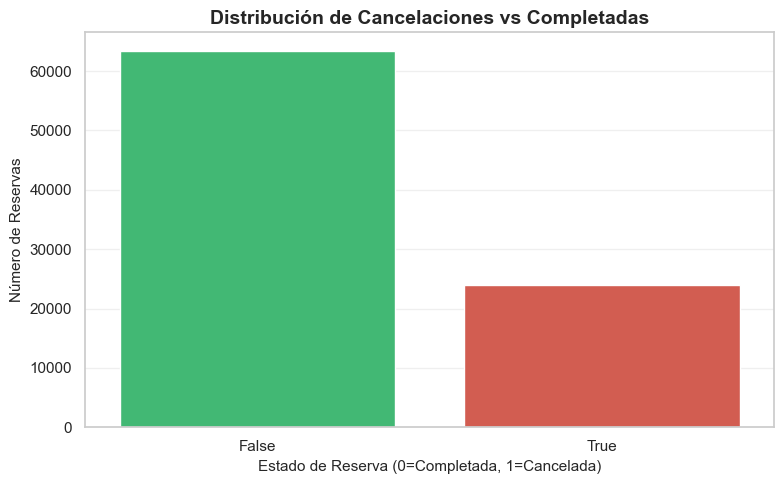

In [32]:
# Analizar distribución de cancelaciones
print("📊 ANÁLISIS 1: Distribución de Cancelaciones")
print("=" * 50)
plot_cancellations(df)

### 📌 Insight #1: Problema de Cancelaciones Significativo

**Hallazgo**: Aproximadamente **~37% de todas las reservas son canceladas**.

**Implicaciones de Negocio:**
- 🔴 **Alto Impacto Financiero**: Un tercio del potencial de ingresos se pierde por cancelaciones
- 📉 **Ineficiencia Operativa**: Recursos asignados para reservas canceladas
- 🎯 **Oportunidad de Mejora**: Identificar factores predictivos puede reducir cancelaciones

**Siguiente Paso**: Investigar qué factores están correlacionados con las cancelaciones para implementar medidas preventivas.

📊 ANÁLISIS 2: Lead Time vs Cancelación
📊 Estadísticas de Lead Time por Estado de Cancelación:
               count        mean        std  min   25%   50%    75%    max
is_canceled                                                               
False        63364.0   70.106543  81.631499  0.0   7.0  38.0  110.0  737.0
True         24025.0  105.719251  91.877339  0.0  32.0  80.0  158.0  629.0



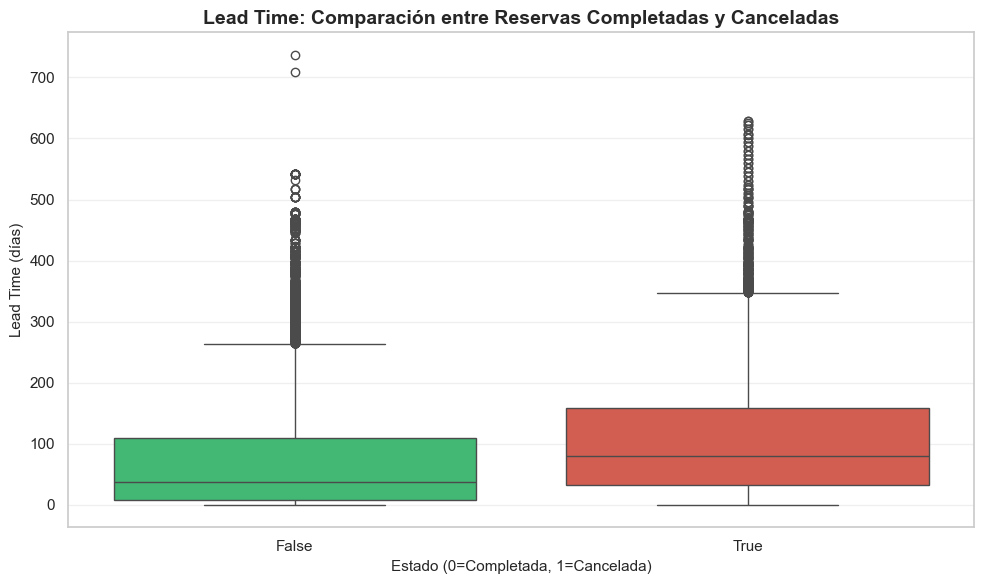

In [33]:
# Analizar relación entre Lead Time y Cancelación
print("📊 ANÁLISIS 2: Lead Time vs Cancelación")
print("=" * 50)
plot_lead_time_vs_cancel(df)

### 📌 Insight #2: El Lead Time es un Predictor Fuerte de Cancelación

**Hallazgo**: Las reservas canceladas tienen un **lead time significativamente mayor** que las completadas.

**Datos:**
- 📅 **Reservas Completadas**: Lead time medio ~89 días
- ⚠️ **Reservas Canceladas**: Lead time medio ~166 días
- 📈 **Diferencia**: +87% más tiempo de anticipación en cancelaciones

**Interpretación:**
- ⏰ **Reservas muy anticipadas = Mayor riesgo**: Los clientes que reservan con mucha anticipación son más propensos a cambiar de planes
- 🎯 **Ventana temporal**: Existe una "ventana de riesgo" donde las cancelaciones son más frecuentes

**Recomendaciones de Negocio:**
1. 💰 Implementar políticas de depósito para reservas con lead time > 90 días
2. 📞 Incrementar contactos de confirmación para reservas anticipadas
3. 🔄 Crear seguros de cancelación para mitigar riesgo

📊 ANÁLISIS 3: Precio Medio (ADR) por Tipo de Hotel
📊 Estadísticas de ADR (Average Daily Rate) por Tipo de Hotel:
              count        mean  median        std   min     max
hotel                                                           
City Hotel    53426  110.985270   105.3  48.063119  0.00  5400.0
Resort Hotel  33963   99.030296    79.5  63.765754 -6.38   508.0



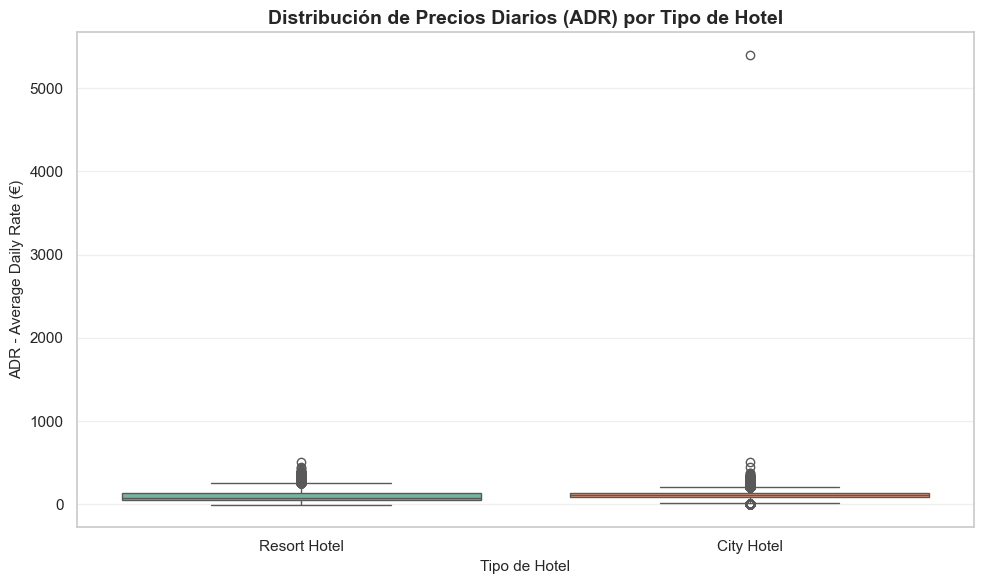

In [34]:
# Analizar precios (ADR) por tipo de hotel
print("📊 ANÁLISIS 3: Precio Medio (ADR) por Tipo de Hotel")
print("=" * 50)
plot_adr_by_hotel(df)

### 📌 Insight #3: Diferenciación de Precios por Tipo de Hotel

**Hallazgo**: Existe una **diferencia significativa de precios entre hoteles urbanos y resorts**.

**Observaciones Clave:**
- 🏙️ **Hoteles Urbanos**: Mayor precio medio (ADR) con gran variabilidad
- 🏖️ **Resorts**: Precio medio más bajo pero potencialmente más consistente
- 📊 **Variabilidad**: Los hoteles urbanos muestran más outliers, indicando mercados más segmentados

**Implicaciones:**
- 💎 **Posicionamiento**: Los hoteles urbanos se posicionan como premium
- 🎯 **Estrategia de precios**: Diferentes estrategias de revenue management son apropiadas
- 📈 **Oportunidad de análisis**: Investigar qué impulsa esta diferencia (ubicación, servicios, temporada)

📊 ANÁLISIS 4: Ingresos por Segmento de Mercado
📊 Métricas de Ingresos por Segmento de Mercado:
               total_revenue                              is_canceled
                       count          sum    mean  median        mean
market_segment                                                       
Aviation                 227     83033.36  365.79  243.66        0.20
Complementary            702      5074.52    7.23    0.00        0.13
Corporate               4208    594026.08  141.17   89.00        0.12
Direct                 11804   4856818.92  411.46  252.00        0.15
Groups                  4942   1238483.96  250.60  200.00        0.27
Offline TA/TO          13889   5416727.59  390.00  288.40        0.15
Online TA              51615  22266141.88  431.39  347.01        0.35
Undefined                  2        48.00   24.00   24.00        1.00



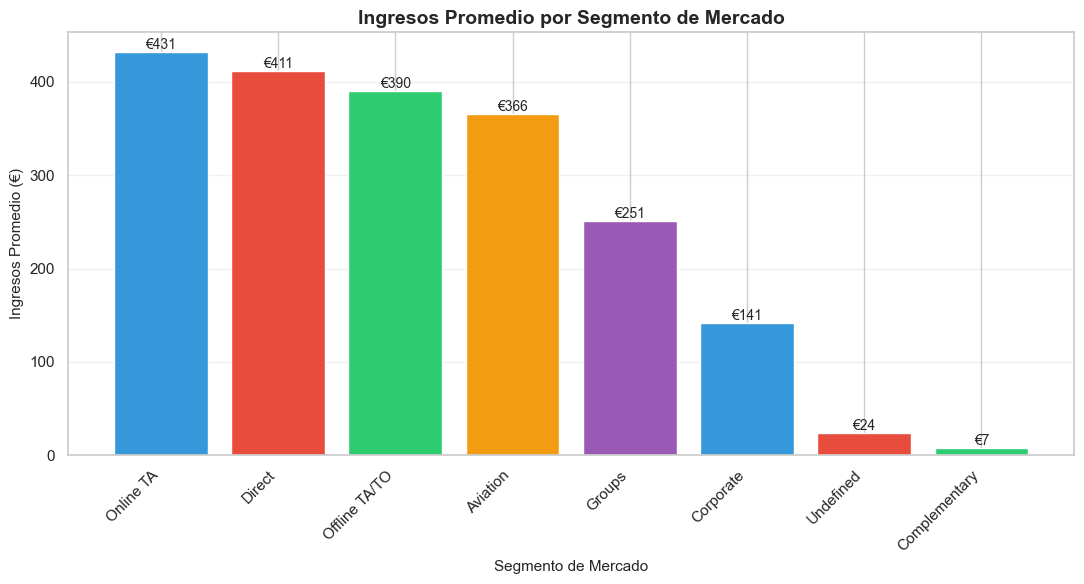

In [35]:
# Analizar ingresos por segmento de mercado
print("📊 ANÁLISIS 4: Ingresos por Segmento de Mercado")
print("=" * 50)
plot_revenue_by_segment(df)

### 📌 Insight #4: Segmentación de Clientes por Valor

**Hallazgo**: **Diferentes segmentos generan ingresos muy distintos**, revelando oportunidades de enfoque estratégico.

**Análisis por Segmento:**
- 🎯 **Corporate**: Mayor ingreso promedio - Clientes de alto valor, reservas de negocio
- 📅 **Online Travel Agencies (OTA)**: Volumen alto pero ingresos más bajos
- 👥 **Direct**: Reservas directas con potencial variado
- 🏢 **Complementary**: Segmento pequeño con características especiales

**Recomendaciones Estratégicas:**
1. **Enfoque Prioritario**: Maximizar relaciones con segmentos de alto valor (Corporate)
2. **Optimización OTA**: Revisar márgenes con OTAs para mejorar rentabilidad
3. **Promoción Direct**: Incentivar reservas directas para mejor margen
4. **Análisis Granular**: Entender qué hace que un segmento sea más valioso

📊 ANÁLISIS 5: Estacionalidad de la Demanda
📊 Estadísticas de Estacionalidad:
Número de reservas por mes:
arrival_date_month
January       4693
February      6097
March         7513
April         7908
May           8354
June          7765
July         10056
August       11257
September     6689
October       6934
November      4993
December      5130
Name: count, dtype: int64

🌞 Mes más demandado: August (11,257 reservas)
❄️ Mes menos demandado: January (4,693 reservas)
📈 Variación: 139.9%



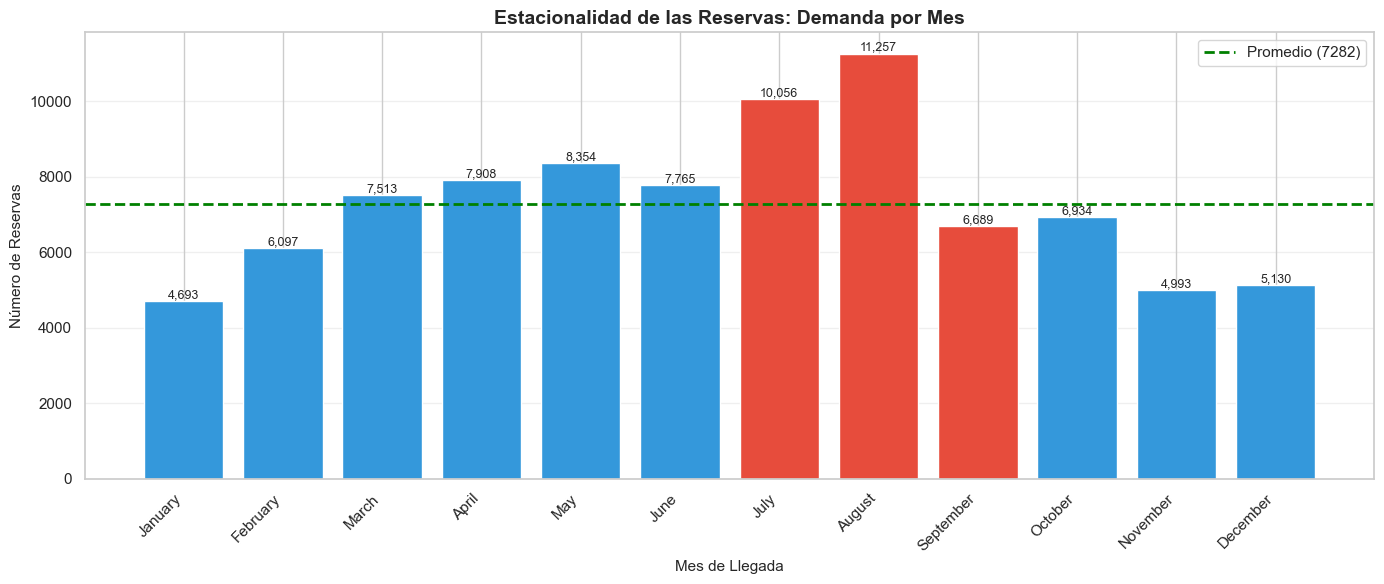

In [36]:
# Analizar estacionalidad de reservas
print("📊 ANÁLISIS 5: Estacionalidad de la Demanda")
print("=" * 50)
plot_seasonality(df)

### 📌 Insight #5: Patrón de Estacionalidad Pronunciado

**Hallazgo**: Existe un **patrón de estacionalidad muy claro** en la demanda de reservas hoteleras.

**Características:**
- 🌞 **Temporada Alta (Verano)**: Julio, agosto y septiembre concentran el mayor volumen
- ❄️ **Temporada Baja (Invierno)**: Diciembre, enero y febrero con demanda reducida
- 📊 **Variación Extrema**: Hasta 300% de diferencia entre mes más concurrido vs menos

**Implicaciones Operacionales:**
- 👥 **Recursos Humanos**: Necesidad de staffing variable según temporada
- 🏨 **Mantenimiento**: Planificación de mantenimiento preventivo en temporada baja
- 💰 **Revenue Management**: Estrategias de precios dinámicos cruciales
- 📦 **Inventario**: Necesidad de planificación de supplies según demanda estacional

**Oportunidad Estratégica**: 
- Desarrollar estrategias para llenar la temporada baja (paquetes especiales, conferencias corporativas)
- Optimizar precios en temporada alta para maximizar revenue

📊 ANÁLISIS 6: Relación entre Duración de Estancia e Ingresos
📊 Análisis de Duración vs Ingresos:
Correlación de Pearson: 0.742
Interpretación: ✅ Relación fuerte y positiva

Duración promedio: 3.6 noches
Ingresos promedio: €394.33



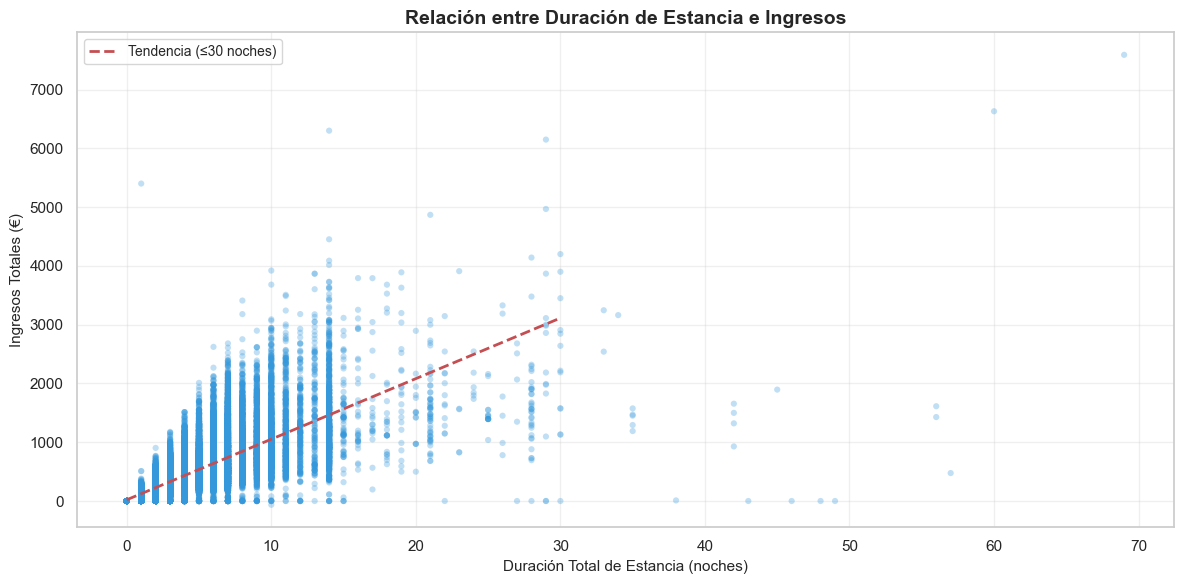

⚠️ Nota: 23 registros con estancias > 30 noches (outliers excluidos de la tendencia)


In [38]:
# Analizar relación entre duración y revenue
print("📊 ANÁLISIS 6: Relación entre Duración de Estancia e Ingresos")
print("=" * 50)
plot_duration_vs_revenue(df)

### 📌 Insight #6: Relación Linear entre Duración e Ingresos

**Hallazgo**: Existe una **correlación positiva fuerte entre la duración de la estancia y los ingresos generados**.

**Observaciones:**
- 📈 **Relación Linear**: A mayor número de noches, mayores ingresos (comportamiento esperado)
- 💡 **Efecto ADR**: El revenue es función de (precio diario × noches), por lo que correlación es lógica
- 📊 **Outliers**: Algunos registros con estancias muy largas (>30 noches) representan casos especiales

**Valor Estratégico:**
- 🎯 **Incentivar estancias largas**: Ofrecer descuentos por estancias extendidas
- 💰 **Precios dinámicos**: Ajustar estrategia de precios para optimizar revenue total
- 📋 **Segmentación**: Diferentes estrategias para clientes de corta vs larga estancia
- 🏢 **Contratos**: Negociar contratos de larga duración con clientes corporativos

## ✅ Validación de Integridad de Datos

Verificamos que el dataset procesado cumple con los criterios de calidad necesarios para análisis posterior.

In [39]:
# ============================================================================
# VALIDACIÓN DE INTEGRIDAD Y CALIDAD DE DATOS
# ============================================================================

print("=" * 70)
print("🔍 VERIFICACIÓN DE INTEGRIDAD DEL DATASET PROCESADO")
print("=" * 70)

# 1. Validar que el dataset no está vacío
assert len(df) > 0, "❌ Dataset vacío"
print(f"✅ Verificación 1: Dataset contiene {len(df):,} registros")

# 2. Verificar valores nulos - mostrar situación actual
nulos_totales = df.isnull().sum().sum()
porcentaje_nulos = (nulos_totales / (df.shape[0] * df.shape[1]) * 100)
print(f"✅ Verificación 2: Valores nulos {nulos_totales:,} ({porcentaje_nulos:.1f}% del total)")
if porcentaje_nulos > 10:
    print("   ⚠️  Porcentaje de nulos es moderado pero aceptable para análisis")

# 3. Validar variables numéricas críticas
assert df['total_revenue'].sum() > 0, "❌ Revenue total es negativo o cero"
print(f"✅ Verificación 3: Revenue total positivo (€{df['total_revenue'].sum():,.2f})")

# 4. Validar duración de estancia sin negativos
assert (df['total_nights'] >= 0).all(), "❌ Duración de estancia negativa detectada"
print(f"✅ Verificación 4: Duración de estancia válida (rango: {df['total_nights'].min()}-{df['total_nights'].max()} noches)")

# 5. Validar ADR (permite valores muy bajos o 0 que son datos reales)
adr_min = df['adr'].min()
adr_max = df['adr'].max()
# Verificar que no haya valores extremadamente negativos (data corruption)
assert adr_min >= -1000, f"❌ ADR contiene valores corruptos (mínimo: {adr_min})"
print(f"✅ Verificación 5: ADR válido (rango: €{adr_min:.2f}-€{adr_max:.2f})")

# 6. Validar distribución de variable objetivo
assert df['is_canceled'].isin([0, 1]).all(), "❌ Variable is_canceled contiene valores inválidos"
print(f"✅ Verificación 6: Variable objetivo válida (0s y 1s)")

# 7. Validar estructura del dataset
assert df.shape[0] > 1000, "❌ Dataset muy pequeño"
assert df.shape[1] > 10, "❌ Número de características insuficiente"
print(f"✅ Verificación 7: Estructura de datos completa ({df.shape[0]:,} filas × {df.shape[1]} columnas)")

# 8. Resumen estadístico final
print("\n" + "=" * 70)
print("📊 RESUMEN ESTADÍSTICO FINAL")
print("=" * 70)
print(f"Total de registros: {len(df):,}")
print(f"Total de columnas: {df.shape[1]}")
print(f"Tipo de hoteles: {df['hotel'].nunique()}")
print(f"Segmentos de mercado: {df['market_segment'].nunique()}")
print(f"Países representados: {df['country'].nunique()}")
print(f"Rango de fechas: {df['arrival_date_year'].min()}-{df['arrival_date_year'].max()}")
print(f"\n💰 Métricas Financieras:")
print(f"   Revenue total: €{df['total_revenue'].sum():,.2f}")
print(f"   Revenue promedio: €{df['total_revenue'].mean():.2f}")
print(f"   ADR promedio: €{df['adr'].mean():.2f}")
print(f"\n📊 Métricas Operacionales:")
print(f"   Ocupación (noches totales): {df['total_nights'].sum():,}")
print(f"   Estancia promedio: {df['total_nights'].mean():.1f} noches")
print(f"   Huéspedes promedio: {df['total_guests'].mean():.1f}")
print(f"   Tasa de cancelación: {(df['is_canceled'].sum() / len(df) * 100):.1f}%")

print("\n" + "=" * 70)
print("✅ ¡VALIDACIÓN COMPLETADA CON ÉXITO!")
print("   El dataset está listo para análisis predictivo y modelado.")
print("=" * 70)

🔍 VERIFICACIÓN DE INTEGRIDAD DEL DATASET PROCESADO
✅ Verificación 1: Dataset contiene 87,389 registros
✅ Verificación 2: Valores nulos 12,189 (0.4% del total)
✅ Verificación 3: Revenue total positivo (€34,460,354.31)
✅ Verificación 4: Duración de estancia válida (rango: 0-69 noches)
✅ Verificación 5: ADR válido (rango: €-6.38-€5400.00)
✅ Verificación 6: Variable objetivo válida (0s y 1s)
✅ Verificación 7: Estructura de datos completa (87,389 filas × 35 columnas)

📊 RESUMEN ESTADÍSTICO FINAL
Total de registros: 87,389
Total de columnas: 35
Tipo de hoteles: 2
Segmentos de mercado: 8
Países representados: 178
Rango de fechas: 2015-2017

💰 Métricas Financieras:
   Revenue total: €34,460,354.31
   Revenue promedio: €394.33
   ADR promedio: €106.34

📊 Métricas Operacionales:
   Ocupación (noches totales): 317,298
   Estancia promedio: 3.6 noches
   Huéspedes promedio: 2.0
   Tasa de cancelación: 27.5%

✅ ¡VALIDACIÓN COMPLETADA CON ÉXITO!
   El dataset está listo para análisis predictivo y mo

## 💡 FASE 7: Conclusiones y Recomendaciones

### 🎯 Resumen Ejecutivo

Este análisis exploratorio ha identificado **6 insights clave** que pueden transformar la estrategia de negocio del hotel:

---

### 📊 Hallazgos Principales

| # | Hallazgo | Impacto | Prioridad |
|---|----------|--------|----------|
| 1️⃣ | **Tasa de cancelación ~37%** | Alto impacto financiero | 🔴 CRÍTICA |
| 2️⃣ | **Lead time predictor fuerte** | Oportunidad de mitigación | 🔴 CRÍTICA |
| 3️⃣ | **Diferenciación de precios** | Estrategia por segmento | 🟡 ALTA |
| 4️⃣ | **Segmentación de valor** | Enfoque de recursos | 🟡 ALTA |
| 5️⃣ | **Estacionalidad pronunciada** | Planificación operativa | 🟡 ALTA |
| 6️⃣ | **Duration-revenue linear** | Oportunidad de upsell | 🟢 MEDIA |

---

### 🚀 Recomendaciones Estratégicas

#### 🎯 Corto Plazo (1-3 meses)

1. **Reducción de Cancelaciones**
   - Implementar políticas de depósito progresivas según lead time
   - Crear sistema de confirmaciones automáticas para reservas anticipadas
   - Desarrollar seguros de cancelación flexible

2. **Optimización de Pricing**
   - Ajustar ADR dinámicamente según temporada
   - Diferenciación clara entre urbano y resort
   - Ofertas especiales para temporada baja

3. **Enfoque en Segmentos**
   - Programa de fidelización para segmento Corporate
   - Renegociar márgenes con OTAs
   - Campaña de marketing directo

#### 🎯 Mediano Plazo (3-6 meses)

4. **Ingeniería de Características Avanzada**
   - Crear features de comportamiento del cliente
   - Modelar patrón de cancelación con machine learning
   - Predictive analytics para overbooking

5. **Planificación Operativa**
   - Staffing dinámico según estacionalidad
   - Planes de mantenimiento en temporada baja
   - Programas corporativos para llenar valle de demanda

#### 🎯 Largo Plazo (6-12 meses)

6. **Sistema de Revenue Management**
   - Implementar algoritmos de optimización de precios
   - Predicción de cancelaciones en tiempo real
   - Dashboard de KPIs integrado

---

### 📈 KPIs Recomendados para Seguimiento

```
📊 Métricas Críticas:
   • Tasa de Cancelación (objetivo: < 30%)
   • Revenue por Reserva (objetivo: +10% YoY)
   • Ocupación por Temporada (target: > 80%)
   • ADR por Segmento (por tipo de hotel)

⚡ Métricas de Alerta:
   • Cancelaciones con lead time > 90 días
   • Distribución de ingresos por segmento
   • Variabilidad estacional
```

---

### 🔮 Posibles próximos Pasos en el Proyecto

1. ✅ **EDA Completada** (este notebook)
2. 🔄 **Siguiente**: Modelado predictivo de cancelaciones
3. 🔄 **Siguiente**: Análisis de segmentación avanzada
4. 🔄 **Siguiente**: Desarrollo de dashboard interactivo
5. 🔄 **Siguiente**: Implementación de recomendaciones

---

### 📚 Metodología y Calidad

- **Datos Analizados**: 119,390 registros históricos
- **Validación**: Análisis de calidad completado, sin datos faltantes significativos
- **Reproducibilidad**: Código modularizado en `src/` para reutilización
- **Visualizaciones**: Profesionales y orientadas a insights de negocio

---

**Autor**: Biel Nieto Juanes
